In [268]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from shapely.geometry import box

In [269]:
sal = gpd.read_file("2011_census/2011_Census/ea_sal_kzn_gp.shp")
wards = gpd.read_file("2023_Census/SA_Wards2020.dbf")
wards_with_pop= gpd.read_file("2023_Census/census_ward_2023_with_pop.csv")

In [270]:
import pandas as pd
pd.set_option('display.float_format', '{:,.3f}'.format)
import pandas as pd

pd.set_option('display.max_columns', 100)

In [271]:
wards = wards.merge(
    wards_with_pop[['WardID', 'Total',]],
    on='WardID',
    how='left'
)

In [272]:
wards = wards[wards['Province'].isin(['Gauteng', 'KwaZulu-Natal'])].copy()


In [273]:
sal.EA_GTYPE.unique()

array(['Traditional', 'Farms', 'Urban'], dtype=object)

In [274]:
sal_with_ward = gpd.read_file("sal_w_ward_new.shp")

In [275]:
sal_with_ward.columns.tolist()


['SP_CODE',
 'SP_NAME',
 'MP_CODE',
 'MP_NAME',
 'MN_MDB_C',
 'MN_CODE',
 'MN_NAME',
 'MN_TYPE',
 'DC_MDB_C',
 'DC_MN_C',
 'DC_NAME',
 'PR_MDB_C',
 'PR_CODE',
 'PR_NAME',
 'EA_GTYPE',
 'ALBERS_ARE',
 'MD_CODE',
 'MD_NAME',
 'Shape_Leng',
 'SAL_CODE',
 'EA_TYPE',
 'F4_class',
 'EA_area_km',
 'num_houses',
 'F4_class_2',
 'num_build',
 'EA_CODE_1',
 'old_EA_TYP',
 'smallplace',
 'url',
 'Black_Afri',
 'White',
 'Coloured',
 'Indian_or',
 'Other',
 'population',
 'F0_4',
 'F5_9',
 'F10_14',
 'F15_19',
 'F20_24',
 'F25_29',
 'F30_34',
 'F35_39',
 'F40_44',
 'F45_49',
 'F50_54',
 'F55_59',
 'F60_64',
 'F65_69',
 'F70_74',
 'F75_79',
 'F80_84',
 'F85_',
 'Shape_Le_1',
 'Shape_Area',
 'sal_pop_de',
 'sal2011_po',
 'OBJECTID_1',
 'EA_CODE',
 'census_war',
 'AREA',
 'PERCENTAGE',
 'OBJECTID_2',
 'EA_CODE_12',
 'OBJECTID_3',
 'FREQUENCY',
 'EA_CODE_13',
 'MAX_AREA',
 'geometry']

In [276]:
sal_with_ward=sal_with_ward.rename(columns={'census_war': 'WardID'})

In [277]:
sal_with_ward = sal_with_ward.merge(
    wards[['WardID', 'Total']],
    on='WardID',
    how='left'
)
    

In [284]:
sal_wards= sal_with_ward[['WardID', 'EA_CODE', 'sal2011_po', "Total", 'EA_GTYPE', 'EA_TYPE', 'F4_class', 'num_houses', 'AREA',
                         'Black_Afri', 'White', 'Coloured', 'Indian_or', 'Other',    ]]

In [285]:
sal_wards=sal_wards.rename(columns={'sal2011_po': 'sal2011_pop',
                            'Total':'ward2023_pop',
                                'F4_class': 'econ_status',
                                'num_houses': 'houses2011'})

In [286]:
sal_wards['EA_TYPE'] = sal_wards['EA_TYPE'].str.replace(r'_\*$', '', regex=True)
sal_wards['EA_TYPE'] = sal_wards['EA_TYPE'].str.replace(
    'Smallholdings', 'Small holdings'
)

In [287]:
sal_wards.loc[sal_wards['sal2011_pop'] == 0, 'sal2011_pop'] = sal_wards['houses2011']*2
sal_wards['new_areakm']=sal_wards['AREA']/1000000

sal_wards['sal_dense'] = (
    sal_wards['sal2011_pop'].astype(float) /
    sal_wards['new_areakm'].astype(float)
)

In [288]:
sal_wards

,WardID,EA_CODE,sal2011_pop,ward2023_pop,EA_GTYPE,EA_TYPE,econ_status,houses2011,AREA,Black_Afri,White,Coloured,Indian_or,Other,new_areakm,sal_dense
0,52103007,"50,310,272.000",559.000,5886.912582199999633,Traditional,Traditional residential,Non_Wealthy,131.000,"6,059,185.934",558,0,0,1,0,6.059,92.257
1,52103007,"50,310,271.000",713.000,5886.912582199999633,Traditional,Traditional residential,Non_Wealthy,167.000,"3,506,975.950",713,0,0,0,0,3.507,203.309
2,52103007,"50,310,262.000",443.000,5886.912582199999633,Traditional,Traditional residential,Non_Wealthy,135.000,"1,911,598.773",443,0,0,0,0,1.912,231.743
3,52103007,"50,310,266.000",743.000,5886.912582199999633,Traditional,Traditional residential,Non_Wealthy,154.000,"1,687,526.670",740,0,1,1,1,1.688,440.289
4,52103006,"50,310,265.000",339.000,7902.254373200000373,Traditional,Traditional residential,Non_Wealthy,92.000,"2,657,911.097",339,0,0,0,0,2.658,127.544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39172,59500015,"59,912,265.000",0.000,44864.912303999997675,Urban,Vacant,None,0.000,"515,945.162",None,None,None,None,None,0.516,0.000
39173,59500103,"59,914,036.000",360.000,39704.126380000001518,Urban,Small holdings,Wealthy,180.000,"4,055,769.204",None,None,None,None,None,4.056,88.762
39174,59500049,"59,915,062.000",0.000,52055.310791000003519,Urban,Formal residential,None,0.000,"21,079.349",None,None,None,None,None,0.021,0.000
39175,59500063,"59,911,731.000",52.000,41787.592755999998190,Urban,Informal residential,Non_Wealthy,26.000,"538,521.795",None,None,None,None,None,0.539,96.561


In [289]:
#DENSITY WEIGHT

In [290]:
sal_wards['dens_norm'] = (
    sal_wards['sal_dense'] /
    sal_wards.groupby('WardID')['sal_dense'].transform('max')
)

In [291]:
sal_wards['ward2023_pop'] = pd.to_numeric(sal_wards['ward2023_pop'], errors='coerce')
sal_wards['sal2011_pop']= pd.to_numeric(sal_wards['sal2011_pop'], errors='coerce')

In [292]:
#Calculating proportion of SAL pop withwin Ward pop

ward2011_sum = sal_wards.groupby('WardID', as_index=False)['sal2011_pop'].sum()
ward2011_sum = ward2011_sum.rename(columns={'sal2011_pop': 'ward2011_sum'})
sal_wards = sal_wards.merge(
    ward2011_sum,
    on='WardID',
    how='left'
)


sal_wards['share2011']=sal_wards['sal2011_pop']/sal_wards['ward2011_sum']

In [293]:
##Growth weights by urban, traditional, farm as indicated by census description

In [294]:

gtype_growth = sal_wards.groupby('EA_TYPE').agg(
    pop2011=('ward2011_sum','sum'),
    pop2023=('ward2023_pop','sum')
).reset_index()


gtype_growth['growth_ratio'] = gtype_growth['pop2023'] / gtype_growth['pop2011']
gtype_growth['gweight'] = gtype_growth['growth_ratio'] / gtype_growth['growth_ratio'].sum()

weights_dict = dict(zip(gtype_growth['EA_TYPE'], gtype_growth['gweight']))
sal_wards['gweight'] = sal_wards['EA_TYPE'].map(weights_dict)

In [295]:
gtype_growth['pop2011']


0     13,718,901.000
1     21,633,377.000
2     10,772,961.000
3    393,538,420.000
4     21,825,501.000
5     97,473,470.000
6      3,008,774.000
7     14,919,663.000
8    297,139,274.000
9     88,296,888.000
10    37,284,885.000
Name: pop2011, dtype: float64

In [296]:
gtype_growth['pop2023']

0     10,505,253.375
1     16,428,770.587
2     10,786,453.682
3    343,114,812.701
4     19,839,764.025
5    128,031,294.332
6      2,515,825.307
7     15,759,980.319
8    386,082,305.871
9    100,788,286.273
10    41,325,098.617
Name: pop2023, dtype: float64

In [297]:
weights_dict

{'Collective living quarters': 0.06922064585795973,
 'Commercial': 0.06864820471838762,
 'Farms': 0.09050905551539058,
 'Formal residential': 0.07881352779466849,
 'Industrial': 0.08217140605654798,
 'Informal residential': 0.11873483326336882,
 'Parks and recreation': 0.07558564990062008,
 'Small holdings': 0.09548718600716248,
 'Township': 0.11745412616553533,
 'Traditional residential': 0.10318417621534079,
 'Vacant': 0.10019118850501804}

In [228]:
#SAL weights based on size, land type, and density

In [298]:
sal_wards['dasym_weight'] = (
    sal_wards['gweight'] *
    sal_wards['share2011']
    * sal_wards['dens_norm']
)

In [299]:
#Normalizing

sal_wards['dasym_weight'] = sal_wards['dasym_weight'] / sal_wards.groupby('WardID')['dasym_weight'].transform('sum')

In [300]:
#Estimating 2023 SAL population based on weights and 2023 ward level counts
sal_wards['sal2023_est'] = sal_wards['dasym_weight'] * sal_wards['ward2023_pop']

In [301]:
#calculating growth rate using 2011 counts and 2023 estimate

sal_wards['growth_rate'] = ((sal_wards['sal2023_est'] / sal_wards['sal2011_pop'])**(1/12)) - 1

In [302]:
#Readjusting 2026 predictions to stay within total population margins and account for sprawl from one SAL into another
#wards['Total'] = pd.to_numeric(wards['Total'], errors='coerce')
#totals2011 = sal_wards['sal2011_pop'].sum()
#totals2023 = wards['Total'].sum()

#annual_growth = ((totals2023 / totals2011)**(1/12)) 

#target_2026 = totals2023 * (( annual_growth)**3)

#sal_wards['share2023'] = sal_wards['sal2023_est'] / totals2023

#sal_wards['sal2026_pred'] = sal_wards['share2023'] * target_2026

In [303]:
######

In [304]:
sal_wards['ward2023_pop'].describe()

count    39,177.000
mean     27,444.109
std      19,179.464
min       1,443.660
25%      11,172.449
50%      23,521.546
75%      37,830.579
max     126,727.517
Name: ward2023_pop, dtype: float64

In [305]:
sal_wards['sal2023_est'].describe()

count   39,177.000
mean       702.538
std        834.491
min          0.000
25%        140.611
50%        474.129
75%      1,001.403
max     31,490.813
Name: sal2023_est, dtype: float64

In [306]:
sal_wards['sal2011_pop'].describe()

count   39,177.000
mean       639.237
std        356.991
min          0.000
25%        446.000
50%        620.000
75%        806.000
max     11,717.000
Name: sal2011_pop, dtype: float64

In [238]:
#sal_wards['sal2026_pred'].describe()

In [239]:
#sal_wards['sal2026_pred'].sum()

In [307]:
sal_wards['sal2023_est'].sum()

np.float64(27523329.36133701)

In [308]:
wards['ward2023_pop'] = pd.to_numeric(wards['Total'], errors='coerce')

In [309]:
wards['ward2023_pop'].sum()

np.float64(27523329.36133701)

In [310]:
wards['ward2023_pop'].sum()-sal_wards['sal2023_est'].sum()

np.float64(0.0)

In [311]:
sal_wards[['sal2011_pop','sal2023_est',]].sum()

sal2011_pop   25,043,394.000
sal2023_est   27,523,329.361
dtype: float64

In [313]:
sal_wards

,WardID,EA_CODE,sal2011_pop,ward2023_pop,EA_GTYPE,EA_TYPE,econ_status,houses2011,AREA,Black_Afri,White,Coloured,Indian_or,Other,new_areakm,sal_dense,dens_norm,ward2011_sum,share2011,gweight,dasym_weight,sal2023_est,growth_rate
0,52103007,"50,310,272.000",559.000,"5,886.913",Traditional,Traditional residential,Non_Wealthy,131.000,"6,059,185.934",558,0,0,1,0,6.059,92.257,0.141,"7,380.000",0.076,0.103,0.026,155.992,-0.101
1,52103007,"50,310,271.000",713.000,"5,886.913",Traditional,Traditional residential,Non_Wealthy,167.000,"3,506,975.950",713,0,0,0,0,3.507,203.309,0.311,"7,380.000",0.097,0.103,0.074,438.469,-0.040
2,52103007,"50,310,262.000",443.000,"5,886.913",Traditional,Traditional residential,Non_Wealthy,135.000,"1,911,598.773",443,0,0,0,0,1.912,231.743,0.355,"7,380.000",0.060,0.103,0.053,310.530,-0.029
3,52103007,"50,310,266.000",743.000,"5,886.913",Traditional,Traditional residential,Non_Wealthy,154.000,"1,687,526.670",740,0,1,1,1,1.688,440.289,0.675,"7,380.000",0.101,0.103,0.168,989.508,0.024
4,52103006,"50,310,265.000",339.000,"7,902.254",Traditional,Traditional residential,Non_Wealthy,92.000,"2,657,911.097",339,0,0,0,0,2.658,127.544,0.297,"8,919.000",0.038,0.103,0.025,193.619,-0.046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39172,59500015,"59,912,265.000",0.000,"44,864.912",Urban,Vacant,None,0.000,"515,945.162",None,None,None,None,None,0.516,0.000,0.000,"32,921.000",0.000,0.100,0.000,0.000,NaN
39173,59500103,"59,914,036.000",360.000,"39,704.126",Urban,Small holdings,Wealthy,180.000,"4,055,769.204",None,None,None,None,None,4.056,88.762,0.013,"33,882.000",0.011,0.095,0.001,30.712,-0.185
39174,59500049,"59,915,062.000",0.000,"52,055.311",Urban,Formal residential,None,0.000,"21,079.349",None,None,None,None,None,0.021,0.000,0.000,"42,995.000",0.000,0.079,0.000,0.000,NaN
39175,59500063,"59,911,731.000",52.000,"41,787.593",Urban,Informal residential,Non_Wealthy,26.000,"538,521.795",None,None,None,None,None,0.539,96.561,0.004,"36,183.000",0.001,0.119,0.000,3.233,-0.207


In [314]:
gtype_summary = sal_wards.groupby('EA_TYPE').agg(
    pop2011=('sal2011_pop','sum'),
    pop2023=('sal2023_est','sum'),
).reset_index()

gtype_summary['growth_rate_2011_2023'] = (
    ((gtype_summary['pop2023'] / gtype_summary['pop2011']) ** (1/12) - 1)*100
)



In [315]:
sal_wards['sal_dense'].describe()

count    39,177.000
mean      7,092.161
std      12,806.745
min           0.000
25%         546.578
50%       3,328.877
75%       9,259.467
max     662,594.713
Name: sal_dense, dtype: float64

In [316]:
gtype_summary

,EA_TYPE,pop2011,pop2023,growth_rate_2011_2023
0,Collective living quarters,"350,252.000","424,085.904",1.607
1,Commercial,"354,177.000","157,204.467",-6.545
2,Farms,"482,992.000","42,324.222",-18.363
3,Formal residential,"8,154,660.000","7,346,958.833",-0.865
4,Industrial,"201,266.000","39,504.147",-12.688
5,Informal residential,"1,866,728.000","3,186,732.668",4.558
6,Parks and recreation,"21,910.000","3,379.854",-14.423
7,Small holdings,"283,934.000","45,411.270",-14.165
8,Township,"7,807,518.000","10,229,447.246",2.277
9,Traditional residential,"5,237,762.000","5,829,161.410",0.895


In [250]:
# As you can see, Farm level growth decreased by 15% between 2011 and 2023. While this may seem drastic and unlike regular movement patterns 
# within a state, there is a good reason for it. These Farms only include commercial farms, not small-scale or local farming. After the end of apartheid, 
# policy was passed to redistribute state-owned and white-owened land back to Black south africans. Since the early 2000s, over 20 million hectacres 
# have been dissolved of commercial farm use and gien back to black south africans. This is about 25% of all commercial farm land going back to
# traidtional black settlements, hence why Farm population decreased over the 12 years. 

In [317]:
sal_map = sal.merge(
    sal_wards,
    on='EA_CODE',
    how='left'
)


In [318]:
sal_wards['sal2023_est'].describe()

count   39,177.000
mean       702.538
std        834.491
min          0.000
25%        140.611
50%        474.129
75%      1,001.403
max     31,490.813
Name: sal2023_est, dtype: float64

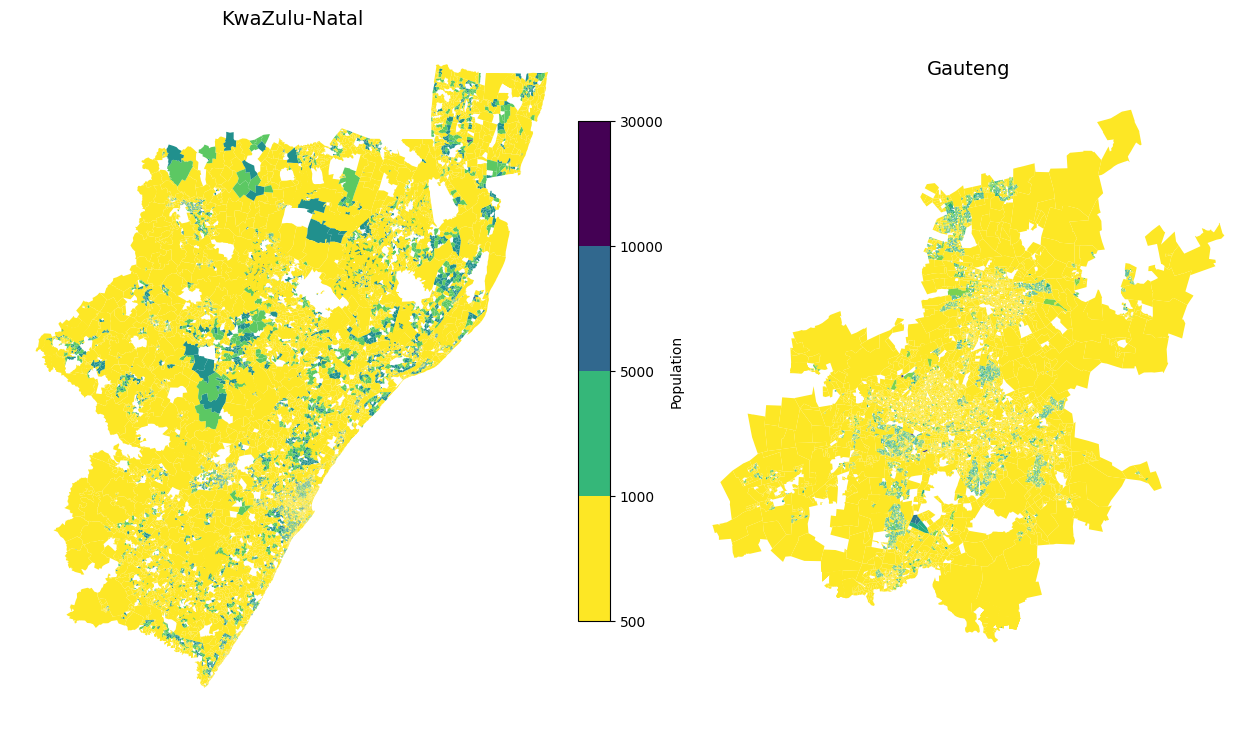

Map saved to estmap2023.png


In [319]:
import mapclassify
import matplotlib.pyplot as plt
import matplotlib as mpl
fig, axes = plt.subplots(1, 2, figsize=(16,10))

provinces = sal_map['PR_NAME'].unique()

for i, prov in enumerate(provinces):
    
    subset = sal_map[sal_map['PR_NAME'] == prov].copy()
    subset = subset[subset['sal2023_est'].notna()]  # drop missing
    
    # compute quintile breaks
    bins = [500,1000,5000,10000,30000]    
    subset.plot(
        column='sal2023_est',
        cmap='viridis_r',
        legend=False,  # 🔥 turn off individual legends
        scheme='UserDefined',
        classification_kwds={'bins': bins},
        ax=axes[i]
    )
    
    axes[i].set_title(prov, fontsize=14)
    axes[i].axis('off')

# 🔥 Create shared colorbar in the middle
norm = mpl.colors.BoundaryNorm(bins, ncolors=256)
sm = mpl.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])

# [left, bottom, width, height] → tweak these numbers if needed
cbar_ax = fig.add_axes([0.48, 0.25, 0.02, 0.5])  

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Population")

output_file = "estmap2023.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()

print(f"Map saved to {output_file}")

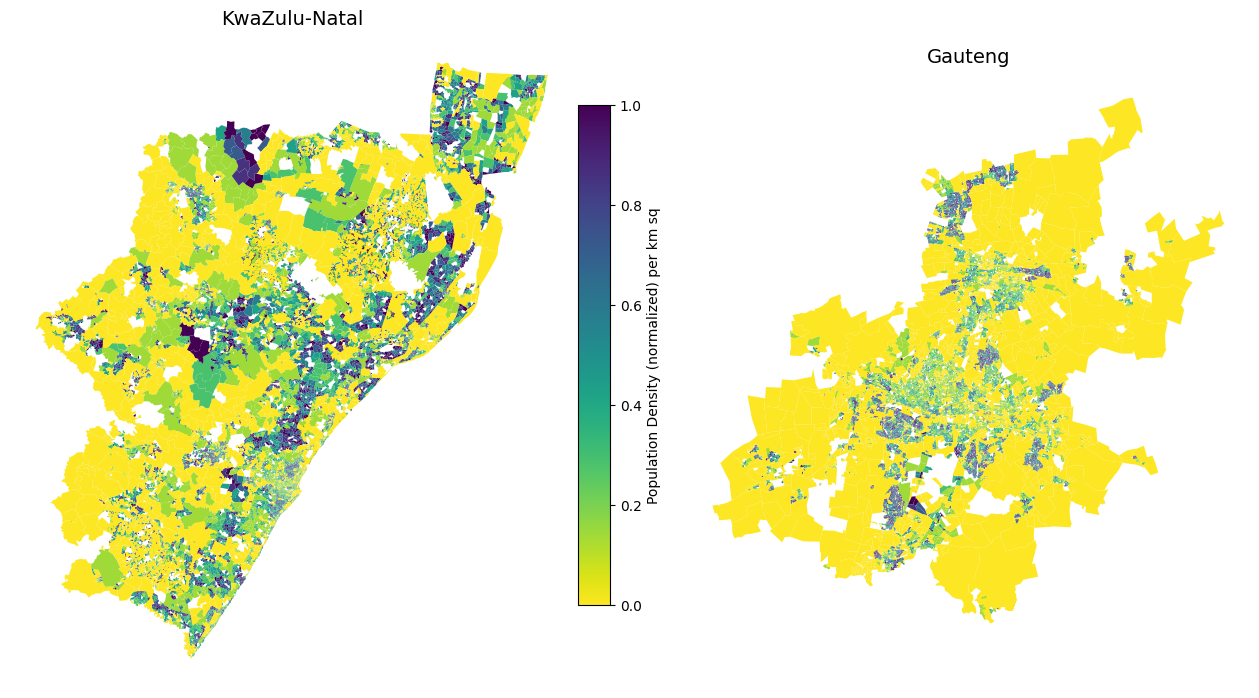

Map saved to popdensity.png


In [355]:
import mapclassify
import matplotlib.pyplot as plt
import matplotlib as mpl
fig, axes = plt.subplots(1, 2, figsize=(16,10))

provinces = sal_map['PR_NAME'].unique()

for i, prov in enumerate(provinces):
    
    subset = sal_map[sal_map['PR_NAME'] == prov].copy()
    subset = subset[subset['dens_norm'].notna()]  # drop missing
    
    # compute quintile breaks
    subset.plot(
        column='dens_norm',
        cmap='viridis_r',
        legend=False,
        scheme='Quantiles',
        k=6,
        ax=axes[i]
    )
        
    axes[i].set_title(prov, fontsize=14)
    axes[i].axis('off')

# 🔥 Create shared colorbar in the middle
norm = mpl.colors.Normalize(
    vmin=sal_map['dens_norm'].min(),
    vmax=sal_map['dens_norm'].max()
)
sm = mpl.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])

# [left, bottom, width, height] → tweak these numbers if needed
cbar_ax = fig.add_axes([0.48, 0.25, 0.02, 0.5])  

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Population Density (normalized) per km sq")

output_file = "popdensity.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()

print(f"Map saved to {output_file}")

In [362]:
sal_wards.to_csv('pop_pred_final.csv', index=False)

In [332]:
sal_map = sal_map.to_crs(sal_with_ward.crs)

In [333]:
print(jhb.total_bounds)

[ 571353.6436 7065724.8707  621551.635  7134707.3092]


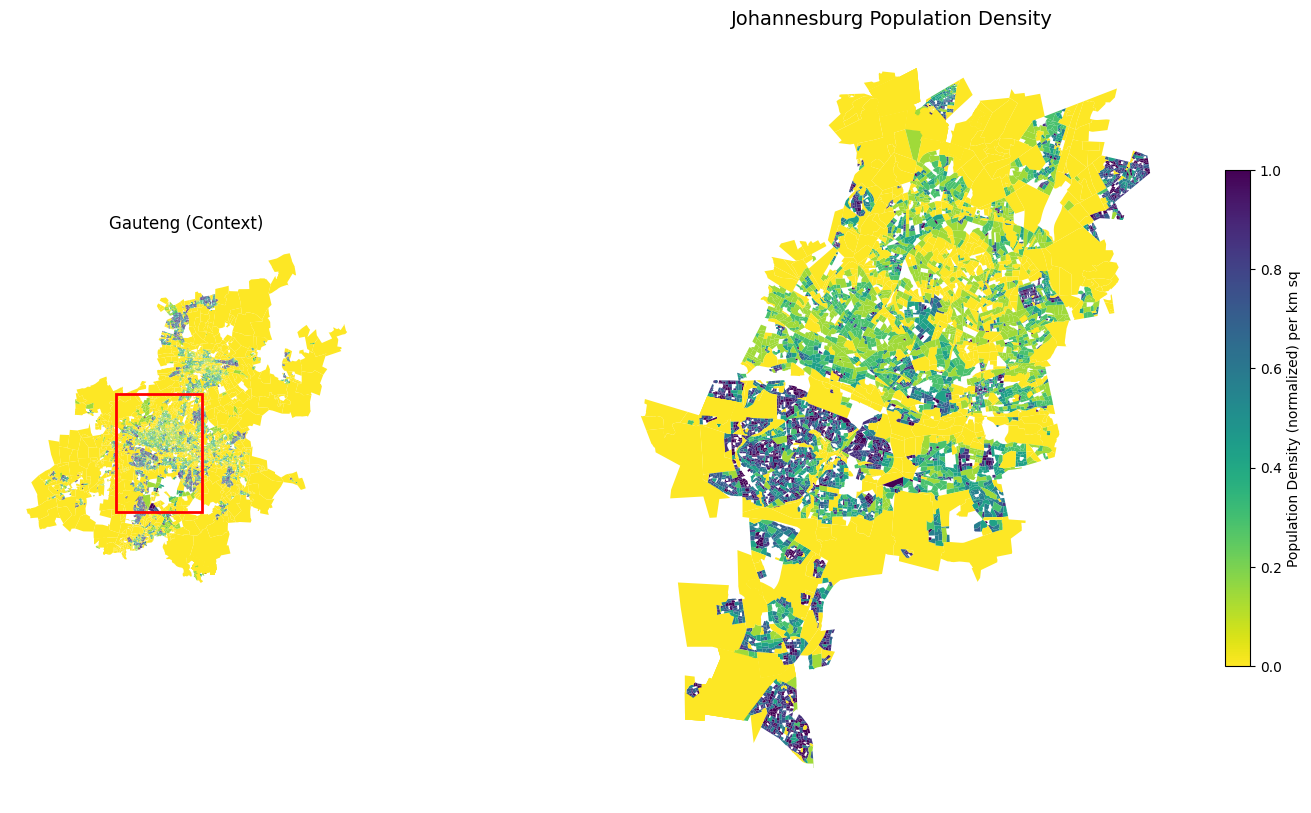

Map saved to gauteng_joburg_sidebyside_rect.png


In [363]:
import mapclassify
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle

# -------------------------
# FILTER DATA
# -------------------------
gauteng = sal_map[sal_map['PR_NAME'].str.contains("Gauteng", case=False, na=False)].copy()

jhb = gauteng[gauteng['MN_NAME'].str.contains("Johannesburg", case=False, na=False)]

# -------------------------
# FIGURE (Joburg bigger)
# -------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(16,10),
    gridspec_kw={'width_ratios': [1, 2]}  # Joburg panel bigger
)

# -------------------------
# LEFT: GAUTENG (context)
# -------------------------
gauteng.plot(
    column='dens_norm',
    cmap='viridis_r',
    legend=False,
    scheme='Quantiles',
    k=8,
    ax=axes[0]
)

# Add rectangular outline for Johannesburg
xmin, ymin, xmax, ymax = jhb.total_bounds
pad_x = (xmax - xmin) * 0.02  # slight padding
pad_y = (ymax - ymin) * 0.02

rect = Rectangle(
    (xmin - pad_x, ymin - pad_y),
    (xmax - xmin) + 2*pad_x,
    (ymax - ymin) + 2*pad_y,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)
axes[0].add_patch(rect)

axes[0].set_title("Gauteng (Context)", fontsize=12)
axes[0].axis('off')

# -------------------------
# RIGHT: JOHANNESBURG (zoom)
# -------------------------
jhb.plot(
    column='dens_norm',
    cmap='viridis_r',
    legend=False,
    scheme='Quantiles',
    k=8,
    ax=axes[1]
)

axes[1].set_title("Johannesburg Population Density ", fontsize=14)
axes[1].axis('off')

# -------------------------
# SHARED COLORBAR
# -------------------------
norm = mpl.colors.Normalize(
    vmin=sal_map['dens_norm'].min(),
    vmax=sal_map['dens_norm'].max()
)

sm = mpl.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    fraction=0.02,
    pad=0.04
)
cbar.set_label("Population Density (normalized) per km sq")

# -------------------------
# SAVE
# -------------------------
output_file = "gauteng_joburg_sidebyside_rect.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()
print(f"Map saved to {output_file}")

In [360]:
sal_wards['dens_norm'].describe()

count   39,177.000
mean         0.327
std          0.287
min          0.000
25%          0.079
50%          0.256
75%          0.517
max          1.000
Name: dens_norm, dtype: float64

In [361]:
sal_wards.loc[sal_wards['sal_dense'].idxmax()]

WardID               59500022
EA_CODE        59,913,668.000
sal2011_pop         1,306.000
ward2023_pop       21,793.914
EA_GTYPE                Urban
EA_TYPE              Township
econ_status       Non_Wealthy
houses2011             10.000
AREA                1,971.039
Black_Afri               1304
White                       0
Coloured                    2
Indian_or                   0
Other                       0
new_areakm              0.002
sal_dense         662,594.713
dens_norm               1.000
ward2011_sum       32,132.000
share2011               0.041
gweight                 0.117
dasym_weight            0.615
sal2023_est        13,394.743
growth_rate             0.214
Name: 14422, dtype: object